Traditional risk parity uses a quadratic optimizer

A cutting edge technique called Hierarchical Risk Parity (HRP) uses graph theory and machine learning to build a hierarchical structure of the investments.

HRP applies graph theory and machine learning to build a diversified portfolio based on the covariance matrix.

HRP is unlike traditional portfolio optimization methods. It can create an optimized portfolio when the covariance matrix is ill-degenerated or singular. This is impossible for quadratic optimizers.

Research has shown HRP to deliver lower out-of-sample variance than traditional optimization methods.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from openbb import obb
import riskfolio as rp

In [2]:
#ETFs list

assets = [
    "XLE", "XLF", "XLU", "XLI", "GDX", 
    "XLK", "XLV", "XLY", "XLP", "XLB", 
    "XOP", "IYR", "XHB", "ITB", "VNQ", 
    "GDXJ", "IYE", "OIH", "XME", "XRT", 
    "SMH", "IBB", "KBE", "KRE", "XTL", 
]

data = (
    obb
    .equity
    .price
    .historical(assets, provider="yfinance")
    .to_df()
    .pivot(columns="symbol", values="close")
)

returns = data.pct_change().dropna()

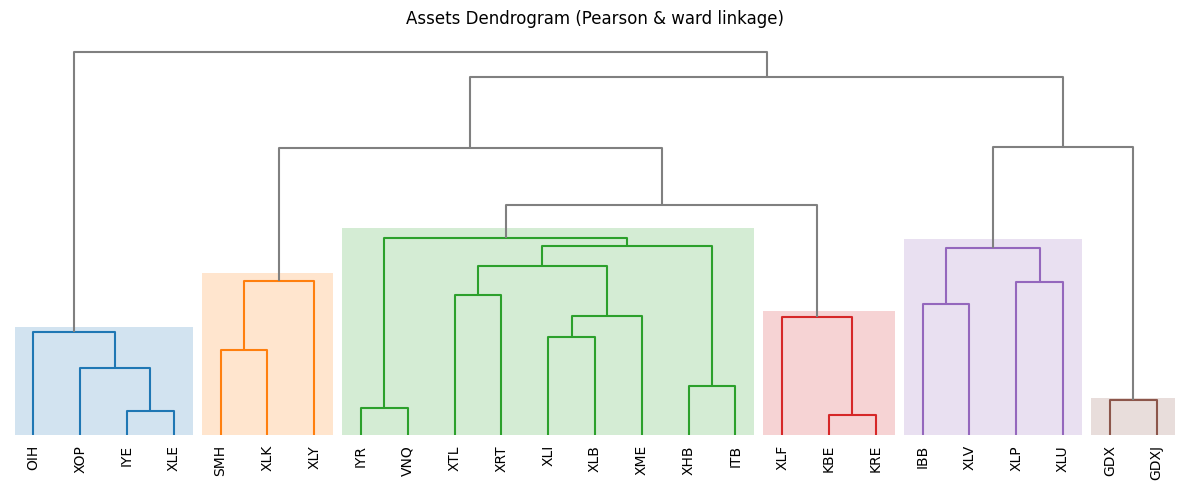

In [3]:
ax = rp.plot_dendrogram(
    returns=returns,
    codependence="pearson", # pearson, spearman, kendall
    linkage="ward", # ward, single, complete, average
    k=None,
    max_k=10,
    leaf_order=True,
    ax=None,
)

The plot visualizes the hierarchical clustering of assets based on their historical return correlations. It illustrates how clusters of assets are merged at each hierarchical level and can give us insight into the correlation structure within a portfolio. The method takes asset returns and a clustering method to compute and plot the dendrogram.

In [11]:
#Building the optimal portfolio based on the hierarchy is one line of code.

port= rp.HCPortfolio(returns=returns)
w = port.optimization(
    model="HRP", # HRP, NCO, IVP, RP, MSR, HERC, HRAD
    codependence="pearson", # pearson, spearman, kendall
    rm="MV", # MV=MinimumVola, MAD, WR
    rf=0.05,# risk free rate
    linkage="ward", # ward, single, complete, average
    max_k=10, # max number of clusters
    leaf_order=True, # leaf order
)

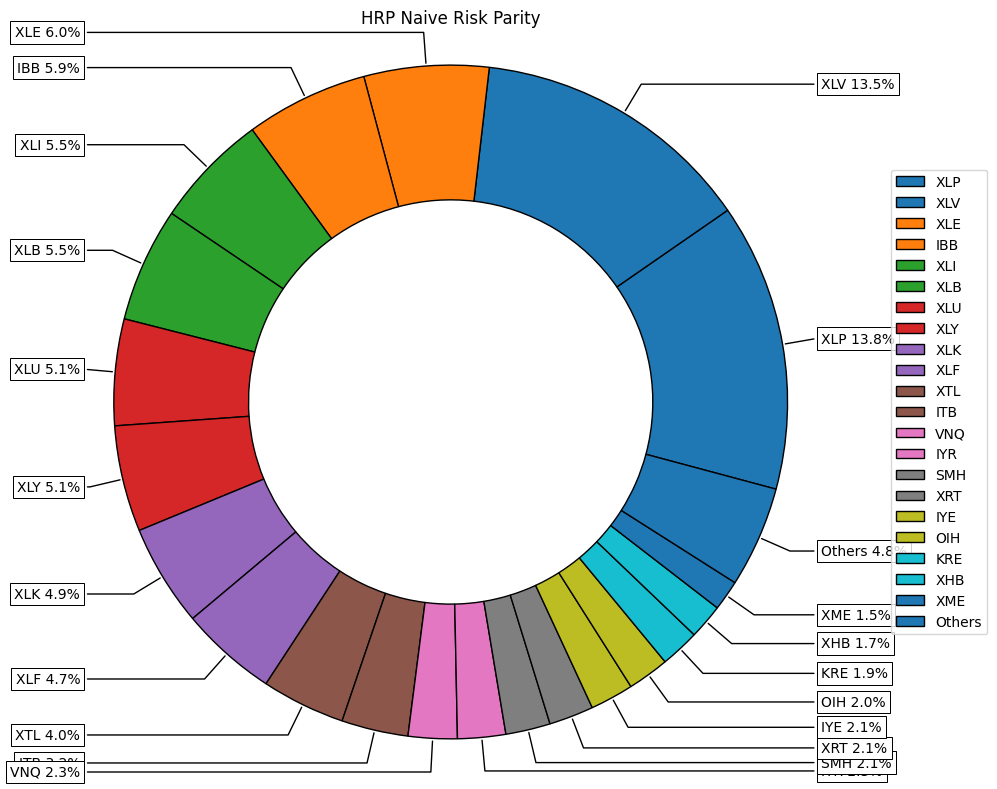

In [12]:
#Visualize the results
ax = rp.plot_pie(
    w=w,
    title="HRP Naive Risk Parity",
    others=0.05,
    nrow=25,
    cmap="tab10",
    height=8,
    width=10,
    ax=None,
)

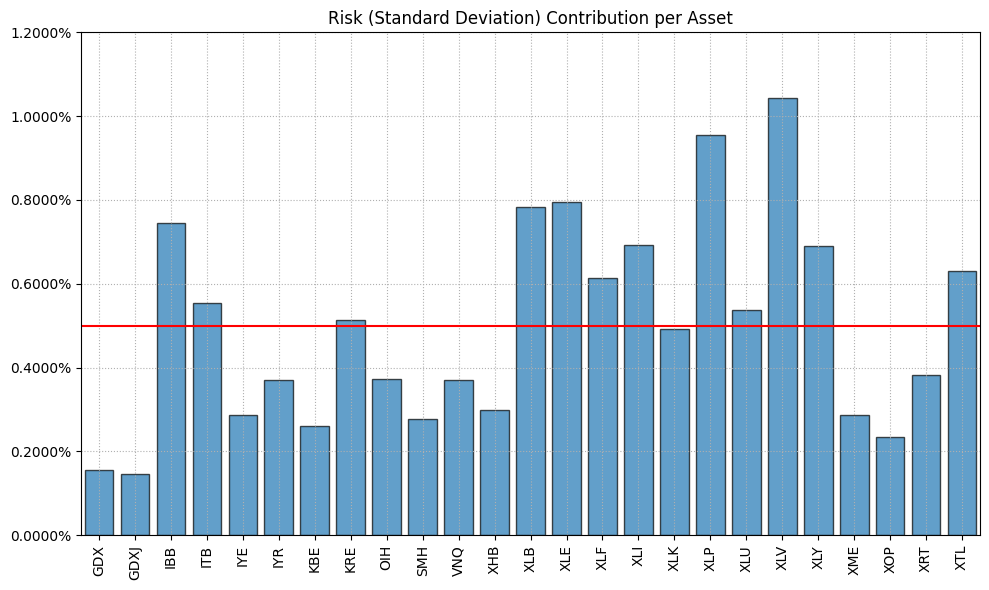

In [13]:
ax = rp.plot_risk_con(
    w=w,
    cov=returns.cov(),
    returns=returns,
    rm="MV",
    rf=0,
    alpha=0.05,
    color="tab:blue",
    height=6,
    width=10,
    t_factor=252,
    ax=None,
)